# --------------------------------------------------------------
# Code for Mamba-MPC on the Van der Pol Oscillator
# --------------------------------------------------------------
## This notebook includes:
 - Data Generation
 - Training of Mamba-MPC 
 - Closed-loop Model Predictive Control (MPC) simulation for multiple Initial Condition using Casadi
 - Closed-loop Mamba-MPC simulation for Reference Tracking vs LSTM-MPC
 - Closed-loop Mamba-MPC simulation for noisy Reference Tracking vs LSTM-MPC
# --------------------------------------------------------------

#### Import Packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from MambaMPC.pscan import pscan
from MambaMPC.mamba_model import Mamba, MambaConfig
from MambaMPC.DataProcessing import HankelMatrices, HankelMatricesStates, HankelMatricesSequences, Sequence2Sequence, Sequence2SequenceStates
from MambaMPC.DataProcessing import BestModelSaver
from MambaMPC.plotting import newfig, savefig
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.gridspec as gridspec
from MambaMPC.functions import multisine, van_der_pol
from scipy.integrate import solve_ivp
torch.set_default_dtype(torch.float64)

## Generate Training Data

(10000, 1)
(10000,)


C:\Users\Michiel\AppData\Local\Temp\ipykernel_75708\919097863.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u_filtered[i+1] = 0.9*u_filtered[i] + 0.1*u_data[i]


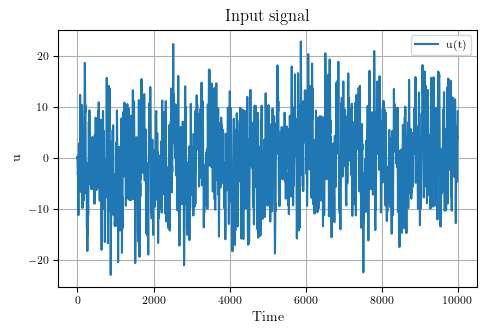

In [41]:
#Amount of Samples
T_period = 10000

# Generate multisine
u_data = 15*multisine(N_points_per_period=T_period, N_periods=1, pmin=1, pmax=1000, n_crest_factor_optim=100,seed=42)

# Generate a single sine 
x = np.linspace(-np.pi, np.pi, T_period)

# Generate a single sine 
x = np.linspace(-np.pi, np.pi, T_period)

# Add the multisine to the single sine wave
u_data = np.array([u_data + np.sin(x)]).T

# Filter the input signal trough a low pass filter
print(u_data.shape)
u_filtered = np.zeros(len(u_data))
print(u_filtered.shape)
for i in range(0,len(u_data)-1):
    u_filtered[i+1] = 0.9*u_filtered[i] + 0.1*u_data[i]


# Plot the final input signal which will be used to generate the data
plt.plot(u_filtered, label='u(t)')
plt.title('Input signal')
plt.xlabel('Time')
plt.ylabel('u')
plt.legend()
plt.grid()
plt.show()

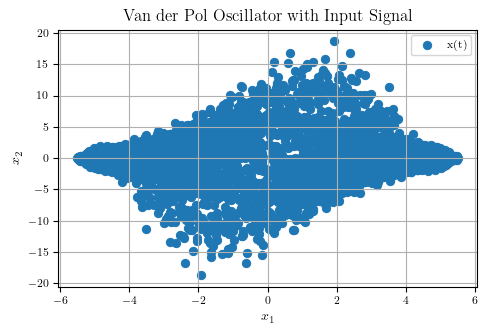

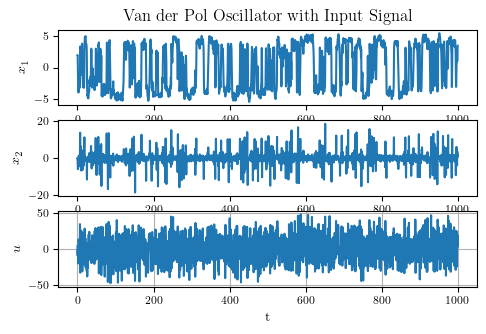

In [42]:
# Parametersd
Ts = 0.1 # Sampling time of the controller
mu = 1.0  # You can change this value to see different behaviors of the van der Pol oscillator
y0 = [2, 0]  # Initial conditions: [x0, dx0]

t_vec = [0]
x = [y0]

# Main loop
for i in range(len(u_data[:,0])):
    u = u_data[i,0]
    # Simulate van de Pol Oscillator for 1 sampling period
    sol = solve_ivp(lambda t, y: van_der_pol(t, y, mu, u),[0, Ts], y0, method='RK45')

    # Take the last value as the new initial condition
    y0 = sol.y[:, -1]
    x.append(y0)  # store state
    t_vec.append((i+1) * Ts)  # store time

# Convert list to numpy array for easier plotting
x = np.array(x)
t_vec = np.array(t_vec)

# Plotting
plt.scatter(x[:, 0], x[:, 1],lw=0.7, label='x(t)')
plt.title('Van der Pol Oscillator with Input Signal')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
plt.grid()
plt.show()

# Plotting
plt.subplot(3,1,1)
plt.plot(t_vec, x[:, 0], label='$x_1$')
plt.title('Van der Pol Oscillator with Input Signal')
plt.ylabel('$x_1$')
plt.xlabel('t')
plt.subplot(3,1,2)
plt.plot(t_vec, x[:, 1], label='$x_2$')
plt.ylabel('$x_2$')
plt.xlabel('t')
plt.subplot(3,1,3)
plt.plot(t_vec[:-1], u_data, label='$u$')
plt.ylabel('$u$')
plt.xlabel('t')
plt.grid()
plt.show()



In [43]:
#Parameters
N = 10
BatchSize = 128
TestSetSize = 500

#Split the data
u_test = u_data[T_period-TestSetSize:,:]
x_test = x[T_period-TestSetSize:,:]
u_data = u_data[:T_period-TestSetSize,:]
x_data = x[:T_period-TestSetSize,:]

u_data = torch.DoubleTensor(u_data)
x_data = torch.DoubleTensor(x_data)
u_test = torch.DoubleTensor(u_test) 
x_test = torch.DoubleTensor(x_test)
print("u_data shape:"+str(u_data.shape))
print("x_data shape:"+str(x_data.shape))


#Training Data
U_0_Nm1, Y_1_N, X0 = HankelMatricesStates(u_data,x_data, N)
X, Y  = Sequence2SequenceStates(X0,U_0_Nm1,Y_1_N)

#Test Data
U_0_Nm1, Y_1_N, X0 = HankelMatricesStates(u_test,x_test, N)
X_test, Y_test = Sequence2SequenceStates(X0,U_0_Nm1,Y_1_N)

# Use GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cuda":
    X = X.cuda()
    Y = Y.cuda()
    X_test = X_test.cuda()
    Y_test = Y_test.cuda()
    print("Using GPU")

#Construct Dataloader
Dataset = TensorDataset(X, Y)
Dataset_test = TensorDataset(X_test, Y_test)
train = DataLoader(Dataset, batch_size=BatchSize, shuffle=False)
test = DataLoader(Dataset_test, batch_size=BatchSize, shuffle=False)

u_data shape:torch.Size([9500, 1])
x_data shape:torch.Size([9500, 2])
Hankel Matrices Generated
Hankel Matrices Generated
Using GPU


## Training Mamba-MPC

In [44]:
class MambaMPC(nn.Module):
    def __init__(self,in_dim,out_dim):
        super().__init__()
        D_model  = 8
        self.config = MambaConfig(d_model=D_model, n_layers=2, expand_factor = 1  , d_conv = 10, d_state = 8, dt_size=2)
        self.lin1 = nn.Linear(in_dim,D_model)
        self.mamba = Mamba(self.config)
        self.MLP = nn.Linear(D_model,out_dim)        
        

    def forward(self,x):
        # print("Input Shape:"+str(x.shape))
        x = self.lin1(x)
        x = self.mamba(x)
        x = self.MLP(x)        
        return x.squeeze(0) 
    

In [ ]:
#Name of File to save the model
filename = "D8_dstate8_Conv10_L2"

#Epochs, Learning Rate and Weight Decay
lr = 1e-3
wd = 1e-5
epochs = 2000
Gamma = 0.998

#Load Model Structure
X_sample,Y_sample = next(iter(train))
batch_size,SequenceLength,Input_dim = X_sample.shape
_,N, Output_dim = Y_sample.shape 
model = MambaMPC(Input_dim, Output_dim)


#Optimizer and Scheduler
opt = torch.optim.AdamW(model.parameters(),lr=lr, weight_decay=wd)

scheduler = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=Gamma)

if device == "cuda":
    model = model.cuda()
    print("Using GPU")

Vallosses = []
Train_loss = []

#Initialize Best Model Saver
best_model_saver = BestModelSaver(filepath="State_dicts/" + filename)

for e in range(epochs):
    model.train()
    running_loss = 0.
    last_loss = 0
    for idx,data in enumerate(train):        
        X,Y = data
        opt.zero_grad()
        z = model(X)
        loss =  torch.mean((z.squeeze(0) - Y) ** 2) / torch.mean((Y) ** 2)   #weighted_mse_loss(z.squeeze(0),Y, weight)
        loss.backward()
        opt.step()
        running_loss += loss.item()
        # print every 10 epoch
    model.eval()
    Vloss = 0.0 # Use a float, not a tensor
    with torch.no_grad():
        for idx, data in enumerate(test):
            # 💡 FIX: Move data to the correct device
            X_val, Y_val = data
            X_val, Y_val = X_val.to(device), Y_val.to(device)
            
            y_eval = model(X_val) # Calling clf(X) is standard
            Val_loss = torch.mean((y_eval - Y_val) ** 2) / torch.mean((Y_val) ** 2)

            # 💡 FIX: Add .item() to prevent memory leak
            Vloss += Val_loss.item()

    # 💡 FIX: Calculate average loss correctly
    average_vloss = Vloss / len(test)
    Vallosses.append(average_vloss)
    
    scheduler.step()
    if e%10 == 0 and e!=0:
        print('Epoch %d | Lossp: %.5f | Validation Loss: %.5f' % (e, running_loss/len(train), average_vloss))
        best_model_saver(current_valid_loss=average_vloss,
                model=model,
                epoch=e, # Current epoch index (0-based)
                optimizer=opt,
                criterion=F.mse_loss)
    Train_loss.append(running_loss/batch_size)

Using GPU
Initialized BestModelSaver. Will save best model to: State_dicts/Test
Epoch 10 | Lossp: 0.11198 | Validation Loss: 0.11698
Validation loss improved from inf to 0.1170.
Epoch 20 | Lossp: 0.06513 | Validation Loss: 0.07035
Validation loss improved from 0.1170 to 0.0704.
Epoch 30 | Lossp: 0.04721 | Validation Loss: 0.05268
Validation loss improved from 0.0704 to 0.0527.
Epoch 40 | Lossp: 0.03627 | Validation Loss: 0.04136
Validation loss improved from 0.0527 to 0.0414.
Epoch 50 | Lossp: 0.02722 | Validation Loss: 0.03067
Validation loss improved from 0.0414 to 0.0307.
Epoch 60 | Lossp: 0.01879 | Validation Loss: 0.02205
Validation loss improved from 0.0307 to 0.0221.
Epoch 70 | Lossp: 0.01250 | Validation Loss: 0.01578
Validation loss improved from 0.0221 to 0.0158.
Epoch 80 | Lossp: 0.00938 | Validation Loss: 0.01216
Validation loss improved from 0.0158 to 0.0122.
Epoch 90 | Lossp: 0.00764 | Validation Loss: 0.01011
Validation loss improved from 0.0122 to 0.0101.
Epoch 100 | Lo

## Model Validation


In [ ]:
#Load dataset
u_test = np.load("Data/u_data_test.npy")
x_test = np.load("Data/x_data_test.npy")

#Parameters
N = 10
BatchSize = 128
TestSetSize = 500

#Convert to torch tensors
u_test = torch.DoubleTensor(u_test).transpose(0,1)
x_test = torch.DoubleTensor(x_test).transpose(0,1)

#Construct Hankel Matrices
U_0_Nm1, Y_1_N, X0 = HankelMatricesStates(u_test,x_test, N)
X_test, Y_test = Sequence2SequenceStates(X0,U_0_Nm1,Y_1_N)

Dataset_test = TensorDataset(X_test, Y_test)

test = DataLoader(Dataset_test, batch_size=BatchSize, shuffle=False)

Hankel Matrices Generated


In [26]:
class MambaMPC(nn.Module):
    def __init__(self,in_dim,out_dim):
        super().__init__()
        D_model  = 8
        self.config = MambaConfig(d_model=D_model, n_layers=6, expand_factor = 1  , d_conv = 10, d_state = 8, dt_size=2)
        self.lin1 = nn.Linear(in_dim,D_model)
        self.mamba = Mamba(self.config)
        self.MLP = nn.Linear(D_model,out_dim)        
        

    def forward(self,x):
        # print("Input Shape:"+str(x.shape))
        x = self.lin1(x)
        x = self.mamba(x)
        x = self.MLP(x)        
        return x.squeeze(0) 

In [ ]:
#Load the chosen model
model = MambaMPC(3,2)
model.load_state_dict(torch.load("State_dicts/D8_dstate8_Conv10_L6" ,map_location=torch.device('cpu'))['model_state_dict'])

<All keys matched successfully>

In [28]:
model.eval().float()

with torch.no_grad():
    for idx, data in enumerate(test):
        X_val, Y_val = data
        y_eval = model(X_val.float()) # Calling clf(X) is standard
        y_hat = y_eval.cpu().numpy()
        if idx ==0:
            yhat_list = y_hat
        else:
            yhat_list = np.concatenate((yhat_list, y_hat), axis=0)

yhat = np.array(yhat_list)

<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
C:\Users\cmich\AppData\Local\Temp\ipykernel_49504\356700494.py:19: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel("$\mathbf{y}$", fontsize=14)
C:\Users\cmich\AppData\Local\Temp\ipykernel_49504\356700494.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(fontsize=10)


Text(0.5, 0, 'Time Steps')

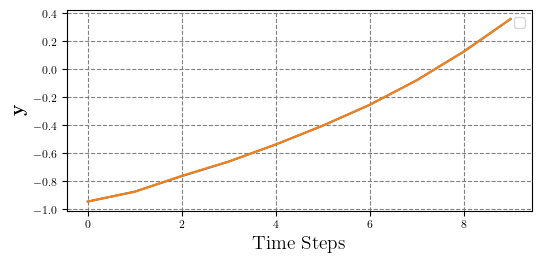

In [ ]:
MAE = np.mean(np.abs(yhat[:,:,0] - Y_test[:,:,0].numpy()),1)
RMAE = np.sqrt(MAE)
NRMAE = RMAE/(np.max(Y_test.numpy())-np.min(Y_test.numpy()))

N_step  = 1
Index  = 301

# Plot the pendulum trajectory together with the input
fig = plt.figure(figsize=(6, 6)) # Adjust figsize as needed

gs = gridspec.GridSpec(2, 1, figure=fig,hspace=0.3, wspace=0.25) #, height_ratios=[1, 1])

# Plot the prediction horizon
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(Y_test[Index,:,0])
ax1.plot(yhat[Index,:,0])
ax1.legend(fontsize=10)
ax1.grid(True, which='both', linestyle='--', linewidth=0.8, color='gray', alpha=1)
ax1.set_ylabel("$\mathbf{y}$", fontsize=14)
ax1.set_xlabel("Time Steps", fontsize=14)



In [39]:

total_params = sum(p.numel() for p in MambaMPC(3,2).parameters())
print(f"Total parameters: {total_params}")

Total parameters: 3418


In [35]:
TotalError = np.sum(MAE)
print("Total Absolute Error:"+str(TotalError))

TotalRError = np.sum(RMAE)
print("Total Root Absolute Error:"+str(TotalRError))

TotalNRError = np.sum(NRMAE)
print("Total Normalized Root Absolute Error:"+str(TotalNRError))

Total Absolute Error:7.009375218634888
Total Root Absolute Error:156.86287597188897
Total Normalized Root Absolute Error:13.008581037202685


In [ ]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# Calculate R-squared
r2_x1 = r2_score(Y_test[:,:,0].numpy(), yhat[:,:,0] )
r2_x2 = r2_score(Y_test[:,:,1].numpy(), yhat[:,:,1] )

print(f"R-squared on validation set: {r2_x1}")
print(f"R-squared on validation set: {r2_x2}")

R-squared on validation set: 0.9999970773774013
R-squared on validation set: 0.9999881552699057


## Closed Loop Initial Conditions

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from MambaMPC.mamba_model import Mamba, MambaConfig, MambaContinuous, SimbaContinuous, SimbaConfig
from casadi import *
import casadi as cs
from casadi.tools import *
import time
from MambaMPC.MambaCasadi import CasadiMamba

In [42]:
def VDP(x1,x2, Ts,u1, mu=1):

    # Calculate the change in angular acceleration
    x1_next = x1+Ts*x2
    x2_next = x2+Ts*(mu*(1-x1**2)*x2-x1+u1)

    return (x1_next, x2_next)

In [46]:
class MambaMPC(nn.Module):
    def __init__(self,in_dim,out_dim):
        super().__init__()
        D_model  = 8
        self.config = MambaConfig(d_model=D_model, n_layers=6, expand_factor = 1  , d_conv = 10, d_state = 8, dt_size=2)
        self.lin1 = nn.Linear(in_dim,D_model)
        self.mamba = Mamba(self.config)
        self.MLP = nn.Linear(D_model,out_dim)        
        

    def forward(self,x):
        # print("Input Shape:"+str(x.shape))
        x = self.lin1(x)
        x = self.mamba(x)
        x = self.MLP(x)        
        return x.squeeze(0) 

In [47]:
def setup_MambaMPC(model, n_y, n_u, N, Q, R, Rd, S):
    """Sets up the SPC controller.

        Args:
        MambaModel: Your system dynamics model (CasADi function).
        n_y: Number of outputs.
        n_u: Number of inputs.
        N: Prediction horizon.
        Tini: Initial state length.
        Q: State tracking cost matrix (n_y x n_y).
        R: Input cost matrix (n_u x n_u).
        Rd: Input rate of change cost matrix (n_u x n_u).
        S: Terminal state cost

    Returns:
        S_spc: The CasADi solver.
        opt_x_num: Numerical instance of optimization variables (for warm-starting).
        opt_p_num: Numerical instance of parameters.
        lbx: Lower bounds on variables.
        ubx: Upper bounds on variables.
    """
    
    # Create optimization variables:
    opt_x = struct_symMX([
        entry('y_N', shape=(N,n_y)),
        entry('u_N', shape=(N,n_u))
    ])

    # Create parameters of the optimization problem
    opt_p = struct_symMX([
        entry('ref', shape=(n_y), repeat=N),
        entry('u_prev', shape=(n_u)),
        entry('x1', shape=(n_u), repeat=1),
        entry('x2', shape=(n_u), repeat=1)
    ])

    # Create numerical instances of the structures (holding all zeros as entries)
    opt_x_num = opt_x(0)
    opt_p_num = opt_p(0)
    
    
    # Define the objective function
    obj = 0
    for k in range(N):
        y_k = opt_x['y_N', k]
        # State tracking cost
        obj += Q * cs.sumsqr(opt_x['y_N', k,0] - opt_p['ref', k])
        # Input cost
        obj += R * cs.sumsqr(opt_x['u_N', k])
        # Input rate of change cost (using u_prev for the first step)
        if k == 0:
            obj += Rd * cs.sumsqr(opt_x['u_N', k] - opt_p['u_prev'])
        else:
            obj += Rd * cs.sumsqr(opt_x['u_N', k] - opt_x['u_N', k-1])

    # # Terminal state cost
    obj += S * cs.sumsqr(opt_x['y_N',N-1,0] - opt_p['ref', N-1]) # Correct indexing for terminal cost


    yN = cs.vertcat(opt_x['y_N'])
    uN = cs.vertcat(opt_x['u_N'])
    inputs = cs.vertcat(cs.horzcat(opt_x['u_N', 0],*opt_p['x1'], *opt_p['x2']))
    for i in range(1,N):
        inputs = cs.vertcat(inputs, cs.horzcat(opt_x['u_N', i],*opt_p['x1'], *opt_p['x2']))

    constraint = []

    States = model.mamba.layers[0].mixer.A_log.detach().numpy().shape[1]
    dt = model.mamba.layers[0].mixer.dt_proj.weight.detach().numpy().shape[1]
    y_vdp =  CasadiMamba(inputs, model,N,dt,States)
    
    constraint = cs.vertcat(yN - y_vdp[:,0])

    # Create lower and upper bound structures and set all values to plus/minus infinity.
    #lbx = opt_x(-np.inf)
    #ubx = opt_x(np.inf)

    # Set only bounds on u_N
    #lbx['u_N'] = -20
    #ubx['u_N'] = 20

    opts = {'ipopt.print_level': 0, 'print_time': 0}
    #opts = {'fatrop.print_level': 0, 'print_time': 0}
    #opts = {"print_header":False, "print_iteration":False,"print_time":False, "print_in": False, "print_out": False}
    # Create Optim
    nlp = {'x': opt_x, 'f':obj, 'g': constraint, 'p': opt_p}
    S_spc = nlpsol('S', 'ipopt', nlp, opts)
    
    return S_spc, opt_x_num, opt_p_num

0
Progress of iteration: 100.0% complete   1
Progress of iteration: 100.0% complete   2
Progress of iteration: 100.0% complete   3
Progress of iteration: 100.0% complete   4
Progress of iteration: 100.0% complete   5
Progress of iteration: 100.0% complete   6
Progress of iteration: 100.0% complete   7
Progress of iteration: 100.0% complete   8
Progress of iteration: 100.0% complete   9
Progress of iteration: 100.0% complete   10
Progress of iteration: 100.0% complete   11
Progress of iteration: 100.0% complete   12
Progress of iteration: 100.0% complete   13
Progress of iteration: 100.0% complete   14
Progress of iteration: 100.0% complete   15
Progress of iteration: 100.0% complete   16
Progress of iteration: 100.0% complete   17
Progress of iteration: 100.0% complete   18
Progress of iteration: 100.0% complete   19
Progress of iteration: 100.0% complete   20
Progress of iteration: 100.0% complete   21
Progress of iteration: 100.0% complete   22
Progress of iteration: 100.0% complete 

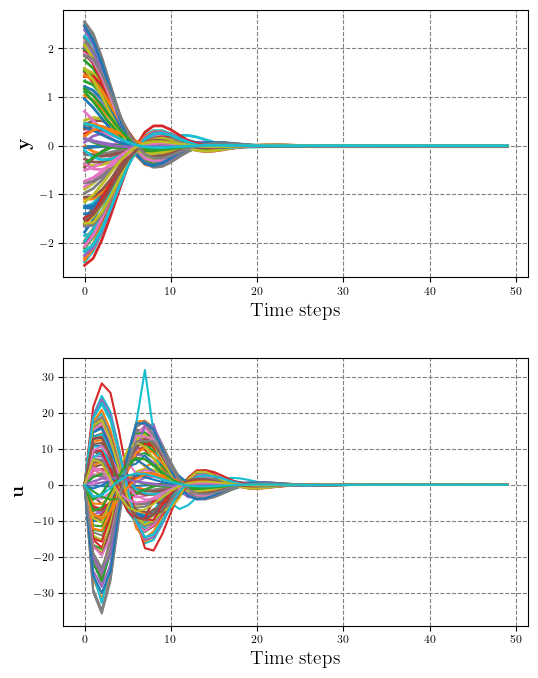

In [48]:

#Sampling Time
Ts = 0.1

# Simulation time
time_range = 8

# Simulation steps
L = round(time_range/Ts)

# Init time
t = np.arange(L+1)*Ts

#Model Variables
N = 10

ref = []
amplitudes = [0]
ref_line = []
for amplitude in amplitudes:
    ref_line.extend([amplitude] * 100)

ref_line = np.array(ref_line)
ref = np.concatenate((ref, ref_line)) 
# ref = 0.4*np.ones(L)

# Initial state
x1_init = np.random.uniform(low=-2.5, high=2.5, size=100)
x2_init = np.random.uniform(low=-2, high=2, size=100)


x1 = np.zeros(L- N + 1)
x2 = np.zeros(L - N+ 1)
u = np.zeros(L)

n_u = 1
n_y = 1


# #Controller Variables
Q = 100
R = 0
Rd = 0.5
S = 100

#Select Model
filename = "D8_dstate8_Conv10_L6"
model = MambaMPC(3 ,2).double()
model.load_state_dict(torch.load("State_dicts/"+filename,  map_location=torch.device('cpu'))['model_state_dict'])


y_solver_vec = []
uN = np.zeros(N)
yN = np.zeros(N)
initial_guess = np.zeros((2*N,1))
CompTime = []
guess_lam_x0 = np.zeros(((n_y+n_u)*N, 1))
uvec_total = []
yvec_total = []
Cost = []
CostList = []
guess_lam_g0 = 0

S_mpc, opt_x_num, opt_p_num = setup_MambaMPC(model,n_y, n_u, N, Q, R, Rd, S)


opt_p_num['ref'] = cs.vertsplit(ref[0:0+N])
opt_p_num['u_prev'] = cs.vertsplit(0)
opt_p_num['x1'] = x1[0]
opt_p_num['x2'] = x2[0]

r = S_mpc(x0 = initial_guess,
            lam_x0 = guess_lam_x0,  # Pass dual guess for x
            lam_g0 = guess_lam_g0,  # Pass dual guess for g
            p=opt_p_num,
            lbg = 0,
            ubg = 0)
uN = np.array(opt_x_num['u_N'])
yN = np.array(opt_x_num['y_N'])
initial_guess = np.concatenate((uN.reshape(n_u*N,1),yN.reshape(n_y*N,1))).reshape((n_y+n_u)*N,1)
guess_lam_x0 = r['lam_x']
guess_lam_g0 = r['lam_g']


for j in range(len(x1_init)):
    print(j)
    x1 = np.zeros(L- N + 1)
    x2 = np.zeros(L - N+ 1) 
    x1[0] = x1_init[j]
    x2[0] = x2_init[j]
    

    r = S_mpc(x0 = initial_guess,
            lam_x0 = guess_lam_x0,  # Pass dual guess for x
            lam_g0 = guess_lam_g0,  # Pass dual guess for g
            p=opt_p_num,
            lbg = 0,
            ubg = 0)
    uN = np.array(opt_x_num['u_N'])
    yN = np.array(opt_x_num['y_N'])
    initial_guess = np.concatenate((uN.reshape(n_u*N,1),yN.reshape(n_y*N,1))).reshape((n_y+n_u)*N,1)
    guess_lam_x0 = r['lam_x']
    guess_lam_g0 = r['lam_g']
    uN = np.zeros(N)
    yN = np.zeros(N)
    uvec = [0.0]
    yvec = []
    
    for k in range(L-N):

        opt_p_num['ref'] = cs.vertsplit(ref[k:k+N])
        opt_p_num['u_prev'] = cs.vertsplit(uvec[k])
        opt_p_num['x1'] = x1[k]
        opt_p_num['x2'] = x2[k]

        # #Noisy update
        # opt_p_num['x1'] = x1[k]+noise_x1
        # opt_p_num['x2'] = x2[k]+noise_x2

        tic = time.time()
        r = S_mpc(x0 = initial_guess,
                lam_x0 = guess_lam_x0,  # Pass dual guess for x
                lam_g0 = guess_lam_g0,  # Pass dual guess for g
                p=opt_p_num,
                lbg = 0,
                ubg = 0)
        toc = time.time()

        CompTime.append(toc - tic)
        opt_x_num.master = r['x']  
        uN = np.array(opt_x_num['u_N']).squeeze(1)
        yN = np.array(opt_x_num['y_N']).squeeze(1)
        Cost.append(np.array(r['f']))
        initial_guess = np.concatenate((uN,yN)).reshape(20,1)
        u0 = opt_x_num['u_N',0].full().reshape(-1,1)
        y_solver = opt_x_num['y_N',0].full().reshape(-1,1)
        y_solver_vec.append(y_solver.item() )
        uvec.append(u0.item())
        #VDP 
        (x1[k+1], x2[k+1]) = VDP(x1[k],x2[k], Ts,u0.item(), mu=1)
        yvec.append(x1[k+1])
        print(f"\rProgress of iteration: {((k) / (L - N-1)) * 100:.1f}% complete   ", end="", flush=True)

    yvec_total.append(yvec)
    uvec_total.append(uvec)
    CostList.append(Cost)

print("Computation Time: ", np.mean(CompTime))

yvec_total = np.vstack(yvec_total)
uvec_total = np.vstack(uvec_total)



fig = plt.figure(figsize=(6, 8)) # Adjust figsize as needed

# Define the grid structure: 2 rows, 2 columns
# We'll use height_ratios to make the bottom plot potentially taller/shorter if desired
gs = gridspec.GridSpec(2, 1, figure=fig,hspace=0.3, wspace=0.25) #, height_ratios=[1, 1])

# Create the first subplot (top-left) - occupies row 0, column 0
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(ref[:50], '-', color = 'tab:blue' ,lw=2.0, label="Reference")
ax1.plot(yvec_total.T[:50,:],'-',lw=2.0, label = "Mamba-MPC")
ax1.set_ylabel(r"$\mathbf{y}$", fontsize=14)
#ax1.legend(fontsize=10)
ax1.grid(True, which='both', linestyle='--', linewidth=0.8, color='gray', alpha=1)
ax1.set_xlabel("Time steps", fontsize=14)

# Create the second subplot (top-right) - occupies row 0, column 1
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(uvec_total.T[:50,:] ,'-', label = "Mamba-MPC")
ax2.grid(True, which='both', linestyle='--', linewidth=0.8, color='gray', alpha=1)
ax2.set_ylabel(r"$\mathbf{u}$", fontsize=14)
ax2.set_xlabel("Time steps", fontsize=14)


# Show the plot
plt.show()

#Save the data for processing
np.save("Data_Mamba/yvec_VDP_MambaMPC_initial_conditions"+filename+".npy", yvec_total)
np.save("Data_Mamba/uvec_VDP_MambaMPC_initial_conditions"+filename+".npy", uvec_total)

#Save the figure
fig.savefig("Figures/VDP_initial_conditions_"+filename+".png")

## Initial Conditions


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from MambaMPC.mamba_model import Mamba, MambaConfig, MambaContinuous, SimbaContinuous, SimbaConfig
from casadi import *
import casadi as cs
from casadi.tools import *
import time
from MambaMPC.MambaCasadi import CasadiMamba
from MambaMPC.plotting import newfig, savefig
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.gridspec as gridspec

In [3]:
def VDP(x1,x2, Ts,u1, mu=1):

    # Calculate the change in angular acceleration
    x1_next = x1+Ts*x2
    x2_next = x2+Ts*(mu*(1-x1**2)*x2-x1+u1)

    return (x1_next, x2_next)

In [4]:
class MambaMPC(nn.Module):
    def __init__(self,in_dim,out_dim):
        super().__init__()
        D_model  = 8
        self.config = MambaConfig(d_model=D_model, n_layers=6, expand_factor = 1  , d_conv = 10, d_state = 8, dt_size=2)
        self.lin1 = nn.Linear(in_dim,D_model)
        self.mamba = Mamba(self.config)
        self.MLP = nn.Linear(D_model,out_dim)        
        

    def forward(self,x):
        # print("Input Shape:"+str(x.shape))
        x = self.lin1(x)
        x = self.mamba(x)
        x = self.MLP(x)        
        return x.squeeze(0) 

In [5]:
def setup_MambaMPC(model, n_y, n_u, N, Q, R, Rd, S):
    """Sets up the SPC controller.

        Args:
        MambaModel: Your system dynamics model (CasADi function).
        n_y: Number of outputs.
        n_u: Number of inputs.
        N: Prediction horizon.
        Tini: Initial state length.
        Q: State tracking cost matrix (n_y x n_y).
        R: Input cost matrix (n_u x n_u).
        Rd: Input rate of change cost matrix (n_u x n_u).
        S: Terminal state cost

    Returns:
        S_spc: The CasADi solver.
        opt_x_num: Numerical instance of optimization variables (for warm-starting).
        opt_p_num: Numerical instance of parameters.
        lbx: Lower bounds on variables.
        ubx: Upper bounds on variables.
    """
    
    # Create optimization variables:
    opt_x = struct_symMX([
        entry('y_N', shape=(N,n_y)),
        entry('u_N', shape=(N,n_u))
    ])

    # Create parameters of the optimization problem
    opt_p = struct_symMX([
        entry('ref', shape=(n_y), repeat=N),
        entry('u_prev', shape=(n_u)),
        entry('x1', shape=(n_u), repeat=1),
        entry('x2', shape=(n_u), repeat=1)
    ])

    # Create numerical instances of the structures (holding all zeros as entries)
    opt_x_num = opt_x(0)
    opt_p_num = opt_p(0)
    
    
    # Define the objective function
    obj = 0
    for k in range(N):
        y_k = opt_x['y_N', k]
        # State tracking cost
        obj += Q * cs.sumsqr(opt_x['y_N', k,0] - opt_p['ref', k])
        # Input cost
        obj += R * cs.sumsqr(opt_x['u_N', k])
        # Input rate of change cost (using u_prev for the first step)
        if k == 0:
            obj += Rd * cs.sumsqr(opt_x['u_N', k] - opt_p['u_prev'])
        else:
            obj += Rd * cs.sumsqr(opt_x['u_N', k] - opt_x['u_N', k-1])

    # # Terminal state cost
    obj += S * cs.sumsqr(opt_x['y_N',N-1,0] - opt_p['ref', N-1]) # Correct indexing for terminal cost


    yN = cs.vertcat(opt_x['y_N'])
    uN = cs.vertcat(opt_x['u_N'])
    inputs = cs.vertcat(cs.horzcat(opt_x['u_N', 0],*opt_p['x1'], *opt_p['x2']))
    for i in range(1,N):
        inputs = cs.vertcat(inputs, cs.horzcat(opt_x['u_N', i],*opt_p['x1'], *opt_p['x2']))

    constraint = []

    States = model.mamba.layers[0].mixer.A_log.detach().numpy().shape[1]
    dt = model.mamba.layers[0].mixer.dt_proj.weight.detach().numpy().shape[1]
    y_vdp =  CasadiMamba(inputs, model,N,dt,States)
    
    constraint = cs.vertcat(yN - y_vdp[:,0])

    # Create lower and upper bound structures and set all values to plus/minus infinity.
    #lbx = opt_x(-np.inf)
    #ubx = opt_x(np.inf)

    # Set only bounds on u_N
    #lbx['u_N'] = -20
    #ubx['u_N'] = 20

    opts = {'ipopt.print_level': 0, 'print_time': 0}
    #opts = {'fatrop.print_level': 0, 'print_time': 0}
    #opts = {"print_header":False, "print_iteration":False,"print_time":False, "print_in": False, "print_out": False}
    # Create Optim
    nlp = {'x': opt_x, 'f':obj, 'g': constraint, 'p': opt_p}
    S_spc = nlpsol('S', 'ipopt', nlp, opts)
    
    return S_spc, opt_x_num, opt_p_num


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

0
Progress of iteration: 100.0% complete   1
Progress of iteration: 100.0% complete   2
Progress of iteration: 100.0% complete   3
Progress of iteration: 100.0% complete   4
Progress of iteration: 100.0% complete   5
Progress of iteration: 100.0% complete   6
Progress of iteration: 100.0% complete   7
Progress of iteration: 100.0% complete   8
Progress of iteration: 100.0% complete   9
Progress of iteration: 100.0% complete   10
Progress of iteration: 100.0% complete   11
Progress of iteration: 100.0% complete   12
Progress of iteration: 100.0% complete   13
Progress of iteration: 100.0% complete   14
Prog

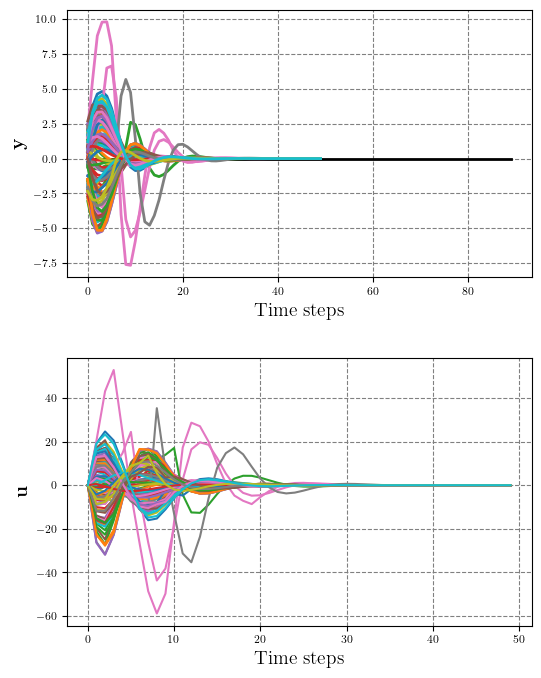

In [6]:
#Sampling Time
Ts = 0.1

# Simulation time
time_range = 10

# Simulation steps
L = round(time_range/Ts)

# Init time
t = np.arange(L+1)*Ts

#Model Variables
N = 10


ref = []
amplitudes = [0]
ref_line = []
for amplitude in amplitudes:
    ref_line.extend([amplitude] * 100)

ref_line = np.array(ref_line)
ref = np.concatenate((ref, ref_line)) 

# Initial state
x1_init = np.random.uniform(low=-2.5, high=2.5, size=100)
x2_init = np.random.uniform(low=-2, high=2, size=100)



x1 = np.zeros(L- N + 1)
x2 = np.zeros(L - N+ 1)
u = np.zeros(L)
n_u = 1
n_y = 1


# #Controller Variables
Q = 100
R = 0
Rd = 0.5
S = 100

#Select Model
filename = "D8_dstate8_Conv10_L6"
model = MambaMPC(3 ,2).double()
model.load_state_dict(torch.load("State_dicts/"+str(filename), weights_only=True, map_location=torch.device('cpu'))['model_state_dict'])


y_solver_vec = []
uN = np.zeros(N)
yN = np.zeros(N)
initial_guess = np.zeros((2*N,1))
CompTime = []
guess_lam_x0 = np.zeros(((n_y+n_u)*N, 1))
uvec_total = []
x1_list = []
x2_list = []
xvec1_total = []
xvec2_total = []

Cost = []
CostList = []
# Dual variable guess for general constraints (lbg, ubg)
# We don't know the size yet, so we pass 0 for the very first solve
guess_lam_g0 = 0

S_mpc, opt_x_num, opt_p_num = setup_MambaMPC(model,n_y, n_u, N, Q, R, Rd, S)


opt_p_num['ref'] = cs.vertsplit(ref[0:0+N])
opt_p_num['u_prev'] = cs.vertsplit(0)
opt_p_num['x1'] = x1[0]
opt_p_num['x2'] = x2[0]

r = S_mpc(x0 = initial_guess,
            lam_x0 = guess_lam_x0,  # Pass dual guess for x
            lam_g0 = guess_lam_g0,  # Pass dual guess for g
            p=opt_p_num,
            lbg = 0,
            ubg = 0)
uN = np.array(opt_x_num['u_N'])
yN = np.array(opt_x_num['y_N'])
initial_guess = np.concatenate((uN.reshape(n_u*N,1),yN.reshape(n_y*N,1))).reshape((n_y+n_u)*N,1)
guess_lam_x0 = r['lam_x']
guess_lam_g0 = r['lam_g']



for j in range(len(x1_init)):
    print(j)
    x1 = np.zeros(L- N + 1)
    x2 = np.zeros(L - N+ 1) 
    x1[0] = x1_init[j]
    x2[0] = x2_init[j]
    

    r = S_mpc(x0 = initial_guess,
            lam_x0 = guess_lam_x0,  # Pass dual guess for x
            lam_g0 = guess_lam_g0,  # Pass dual guess for g
            p=opt_p_num,
            lbg = 0,
            ubg = 0)
    uN = np.array(opt_x_num['u_N'])
    yN = np.array(opt_x_num['y_N'])
    initial_guess = np.concatenate((uN.reshape(n_u*N,1),yN.reshape(n_y*N,1))).reshape((n_y+n_u)*N,1)
    guess_lam_x0 = r['lam_x']
    guess_lam_g0 = r['lam_g']
    uN = np.zeros(N)
    yN = np.zeros(N)
    uvec = [0.0]
    yvec = []
    x1_list = []
    x2_list = []

    for k in range(L-N):

        opt_p_num['ref'] = cs.vertsplit(ref[k:k+N])
        opt_p_num['u_prev'] = cs.vertsplit(uvec[k])
        opt_p_num['x1'] = x1[k]
        opt_p_num['x2'] = x2[k]


        tic = time.time()
        r = S_mpc(x0 = initial_guess,
                lam_x0 = guess_lam_x0,  # Pass dual guess for x
                lam_g0 = guess_lam_g0,  # Pass dual guess for g
                p=opt_p_num,
                lbg = 0,
                ubg = 0)
        toc = time.time()

        CompTime.append(toc - tic)
        opt_x_num.master = r['x']  
        uN = np.array(opt_x_num['u_N']).squeeze(1)
        yN = np.array(opt_x_num['y_N']).squeeze(1)
        Cost.append(np.array(r['f']))
        initial_guess = np.concatenate((uN,yN)).reshape(2*N,1)
        u0 = opt_x_num['u_N',0].full().reshape(-1,1)
        y_solver = opt_x_num['y_N',0].full().reshape(-1,1)
        y_solver_vec.append(y_solver.item() )
        uvec.append(u0.item())

        #VDP 
        (x1[k+1], x2[k+1]) = VDP(x1[k],x2[k], Ts,u0.item(), mu=1)
        x1_list.append(x1[k+1])
        x2_list.append(x2[k+1])
        print(f"\rProgress of iteration: {((k) / (L - N-1)) * 100:.1f}% complete   ", end="", flush=True)
    xvec1_total.append(x2_list)
    xvec2_total.append(x1_list)
    uvec_total.append(uvec)
    CostList.append(Cost)

xvec1 = np.vstack(xvec1_total)
xvec2 = np.vstack(xvec2_total)
uvec =  np.vstack(uvec_total)

fig = plt.figure(figsize=(6, 8)) # Adjust figsize as needed

# Define the grid structure: 2 rows, 2 columns
# We'll use height_ratios to make the bottom plot potentially taller/shorter if desired
gs = gridspec.GridSpec(2, 1, figure=fig,hspace=0.3, wspace=0.25) #, height_ratios=[1, 1])

# Create the first subplot (top-left) - occupies row 0, column 0
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(ref[:L-N], '-', color = 'k' ,lw=2.0, label="Reference")
ax1.plot(xvec1.T[:50,:],'-',lw=2.0, label = "Mamba-MPC")
ax1.set_ylabel(r"$\mathbf{y}$", fontsize=14)
#ax1.legend(fontsize=10)
ax1.grid(True, which='both', linestyle='--', linewidth=0.8, color='gray', alpha=1)
ax1.set_xlabel("Time steps", fontsize=14)

# Create the second subplot (top-right) - occupies row 0, column 1
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(uvec.T[:50,:] ,'-', label = "Mamba-MPC")
#ax2.legend(fontsize=10)
ax2.grid(True, which='both', linestyle='--', linewidth=0.8, color='gray', alpha=1)
ax2.set_ylabel(r"$\mathbf{u}$", fontsize=14)
ax2.set_xlabel("Time steps", fontsize=14)



# Show the plot
plt.show()

## Reference Tracking

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from MambaMPC.mamba_model import Mamba, MambaConfig, MambaContinuous, SimbaContinuous, SimbaConfig
from casadi import *
import casadi as cs
from casadi.tools import *
import time
from MambaMPC.MambaCasadi import CasadiMamba
from MambaMPC.plotting import newfig, savefig
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.gridspec as gridspec

In [56]:
def VDP(x1,x2, Ts,u1, mu=1):

    # Calculate the change in angular acceleration
    x1_next = x1+Ts*x2
    x2_next = x2+Ts*(mu*(1-x1**2)*x2-x1+u1)

    return (x1_next, x2_next)

In [9]:
class MambaMPC(nn.Module):
    def __init__(self,in_dim,out_dim):
        super().__init__()
        D_model  = 8
        self.config = MambaConfig(d_model=D_model, n_layers=6, expand_factor = 1  , d_conv = 10, d_state = 8, dt_size=2)
        self.lin1 = nn.Linear(in_dim,D_model)
        self.mamba = Mamba(self.config)
        self.MLP = nn.Linear(D_model,out_dim)        
        

    def forward(self,x):
        # print("Input Shape:"+str(x.shape))
        x = self.lin1(x)
        x = self.mamba(x)
        x = self.MLP(x)        
        return x.squeeze(0) 

In [10]:
def setup_MambaMPC(model, n_y, n_u, N, Q, R, Rd, S):
    """Sets up the SPC controller.

        Args:
        MambaModel: Your system dynamics model (CasADi function).
        n_y: Number of outputs.
        n_u: Number of inputs.
        N: Prediction horizon.
        Tini: Initial state length.
        Q: State tracking cost matrix (n_y x n_y).
        R: Input cost matrix (n_u x n_u).
        Rd: Input rate of change cost matrix (n_u x n_u).
        S: Terminal state cost

    Returns:
        S_spc: The CasADi solver.
        opt_x_num: Numerical instance of optimization variables (for warm-starting).
        opt_p_num: Numerical instance of parameters.
        lbx: Lower bounds on variables.
        ubx: Upper bounds on variables.
    """
    
    # Create optimization variables:
    opt_x = struct_symMX([
        entry('y_N', shape=(N,n_y)),
        entry('u_N', shape=(N,n_u))
    ])

    # Create parameters of the optimization problem
    opt_p = struct_symMX([
        entry('ref', shape=(n_y), repeat=N),
        entry('u_prev', shape=(n_u)),
        entry('x1', shape=(n_u), repeat=1),
        entry('x2', shape=(n_u), repeat=1)
    ])

    # Create numerical instances of the structures (holding all zeros as entries)
    opt_x_num = opt_x(0)
    opt_p_num = opt_p(0)
    
    
    # Define the objective function
    obj = 0
    for k in range(N):
        y_k = opt_x['y_N', k]
        # State tracking cost
        obj += Q * cs.sumsqr(opt_x['y_N', k,0] - opt_p['ref', k])
        # Input cost
        obj += R * cs.sumsqr(opt_x['u_N', k])
        # Input rate of change cost (using u_prev for the first step)
        if k == 0:
            obj += Rd * cs.sumsqr(opt_x['u_N', k] - opt_p['u_prev'])
        else:
            obj += Rd * cs.sumsqr(opt_x['u_N', k] - opt_x['u_N', k-1])

    # # Terminal state cost
    obj += S * cs.sumsqr(opt_x['y_N',N-1,0] - opt_p['ref', N-1]) # Correct indexing for terminal cost


    yN = cs.vertcat(opt_x['y_N'])
    uN = cs.vertcat(opt_x['u_N'])
    inputs = cs.vertcat(cs.horzcat(opt_x['u_N', 0],*opt_p['x1'], *opt_p['x2']))
    for i in range(1,N):
        inputs = cs.vertcat(inputs, cs.horzcat(opt_x['u_N', i],*opt_p['x1'], *opt_p['x2']))

    constraint = []

    States = model.mamba.layers[0].mixer.A_log.detach().numpy().shape[1]
    dt = model.mamba.layers[0].mixer.dt_proj.weight.detach().numpy().shape[1]
    y_vdp =  CasadiMamba(inputs, model,N,dt,States)
    
    constraint = cs.vertcat(yN - y_vdp[:,0])

    # Create lower and upper bound structures and set all values to plus/minus infinity.
    #lbx = opt_x(-np.inf)
    #ubx = opt_x(np.inf)

    # Set only bounds on u_N
    #lbx['u_N'] = -20
    #ubx['u_N'] = 20

    opts = {'ipopt.print_level': 0, 'print_time': 0}
    #opts = {'fatrop.print_level': 0, 'print_time': 0}
    #opts = {"print_header":False, "print_iteration":False,"print_time":False, "print_in": False, "print_out": False}
    # Create Optim
    nlp = {'x': opt_x, 'f':obj, 'g': constraint, 'p': opt_p}
    S_spc = nlpsol('S', 'ipopt', nlp, opts)
    
    return S_spc, opt_x_num, opt_p_num

0
Progress of iteration: 100.0% complete   

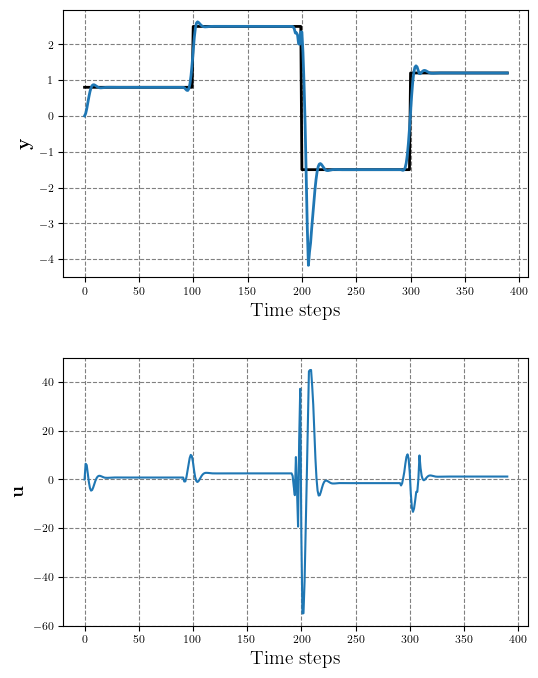

In [11]:
#Sampling Time
Ts = 0.1

# Simulation time
time_range = 40

# Simulation steps
L = round(time_range/Ts)

# Init time
t = np.arange(L+1)*Ts

#Model Variables
N = 10


ref = []
amplitudes = [0.8, 2.5, -1.5, 1.2]
ref_line = []
for amplitude in amplitudes:
    ref_line.extend([amplitude] * 100)

ref_line = np.array(ref_line)
ref = np.concatenate((ref, ref_line)) 

# Initial state
x1_init = [0]
x2_init = [0]


x1 = np.zeros(L- N + 1)
x2 = np.zeros(L - N+ 1)
u = np.zeros(L)
n_u = 1
n_y = 1


# #Controller Variables
Q = 100
R = 0
Rd = 0.5
S = 100

#Select Model
filename = "D8_dstate8_Conv10_L6"
model = MambaMPC(3 ,2).double()
model.load_state_dict(torch.load("State_dicts/"+str(filename), weights_only=True, map_location=torch.device('cpu'))['model_state_dict'])


y_solver_vec = []
uN = np.zeros(N)
yN = np.zeros(N)
initial_guess = np.zeros((2*N,1))
CompTime = []
guess_lam_x0 = np.zeros(((n_y+n_u)*N, 1))
uvec_total = []
xvec1 = []
xvec2 = []
xvec1_total = []
xvec2_total = []

Cost = []
CostList = []
# Dual variable guess for general constraints (lbg, ubg)
# We don't know the size yet, so we pass 0 for the very first solve
guess_lam_g0 = 0

S_mpc, opt_x_num, opt_p_num = setup_MambaMPC(model,n_y, n_u, N, Q, R, Rd, S)


opt_p_num['ref'] = cs.vertsplit(ref[0:0+N])
opt_p_num['u_prev'] = cs.vertsplit(0)
opt_p_num['x1'] = x1[0]
opt_p_num['x2'] = x2[0]

r = S_mpc(x0 = initial_guess,
            lam_x0 = guess_lam_x0,  # Pass dual guess for x
            lam_g0 = guess_lam_g0,  # Pass dual guess for g
            p=opt_p_num,
            lbg = 0,
            ubg = 0)
uN = np.array(opt_x_num['u_N'])
yN = np.array(opt_x_num['y_N'])
initial_guess = np.concatenate((uN.reshape(n_u*N,1),yN.reshape(n_y*N,1))).reshape((n_y+n_u)*N,1)
guess_lam_x0 = r['lam_x']
guess_lam_g0 = r['lam_g']



for j in range(len(x1_init)):
    print(j)
    x1 = np.zeros(L- N + 1)
    x2 = np.zeros(L - N+ 1) 
    x1[0] = x1_init[j]
    x2[0] = x2_init[j]
    

    r = S_mpc(x0 = initial_guess,
            lam_x0 = guess_lam_x0,  # Pass dual guess for x
            lam_g0 = guess_lam_g0,  # Pass dual guess for g
            p=opt_p_num,
            lbg = 0,
            ubg = 0)
    uN = np.array(opt_x_num['u_N'])
    yN = np.array(opt_x_num['y_N'])
    initial_guess = np.concatenate((uN.reshape(n_u*N,1),yN.reshape(n_y*N,1))).reshape((n_y+n_u)*N,1)
    guess_lam_x0 = r['lam_x']
    guess_lam_g0 = r['lam_g']
    uN = np.zeros(N)
    yN = np.zeros(N)
    uvec = [0.0]
    yvec = []

    for k in range(L-N):
        opt_p_num['ref'] = cs.vertsplit(ref[k:k+N])
        opt_p_num['u_prev'] = cs.vertsplit(uvec[k])
        opt_p_num['x1'] = x1[k]
        opt_p_num['x2'] = x2[k]

        # #Noisy update
        # opt_p_num['x1'] = x1[k]+noise_x1
        # opt_p_num['x2'] = x2[k]+noise_x2

        tic = time.time()
        r = S_mpc(x0 = initial_guess,
                lam_x0 = guess_lam_x0,  # Pass dual guess for x
                lam_g0 = guess_lam_g0,  # Pass dual guess for g
                p=opt_p_num,
                lbg = 0,
                ubg = 0)
        toc = time.time()

        CompTime.append(toc - tic)
        opt_x_num.master = r['x']  
        uN = np.array(opt_x_num['u_N']).squeeze(1)
        yN = np.array(opt_x_num['y_N']).squeeze(1)
        Cost.append(np.array(r['f']))
        initial_guess = np.concatenate((uN,yN)).reshape(20,1)
        u0 = opt_x_num['u_N',0].full().reshape(-1,1)
        y_solver = opt_x_num['y_N',0].full().reshape(-1,1)
        y_solver_vec.append(y_solver.item() )
        uvec.append(u0.item())
        #VDP 
        (x1[k+1], x2[k+1]) = VDP(x1[k],x2[k], Ts,u0.item(), mu=1)
        xvec1.append(x1[k+1])
        xvec2.append(x2[k+1])
        print(f"\rProgress of iteration: {((k) / (L - N-1)) * 100:.1f}% complete   ", end="", flush=True)
    xvec2_total.append(xvec2)
    xvec1_total.append(xvec1)
    uvec_total.append(uvec)
    CostList.append(Cost)

xvec1 = np.array(xvec1_total)
xvec2 = np.array(xvec2_total)
uvec = np.array(uvec_total)

fig = plt.figure(figsize=(6, 8)) # Adjust figsize as needed

# Define the grid structure: 2 rows, 2 columns
# We'll use height_ratios to make the bottom plot potentially taller/shorter if desired
gs = gridspec.GridSpec(2, 1, figure=fig,hspace=0.3, wspace=0.25) #, height_ratios=[1, 1])

# Create the first subplot (top-left) - occupies row 0, column 0
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(ref[:L-N], '-', color = 'k' ,lw=2.0, label="Reference")
ax1.plot(xvec1.T[:,:],'-',lw=2.0, label = "Mamba-MPC")
ax1.set_ylabel(r"$\mathbf{y}$", fontsize=14)
#ax1.legend(fontsize=10)
ax1.grid(True, which='both', linestyle='--', linewidth=0.8, color='gray', alpha=1)
ax1.set_xlabel("Time steps", fontsize=14)

# Create the second subplot (top-right) - occupies row 0, column 1
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(uvec.T[:,:] ,'-', label = "Mamba-MPC")
#ax2.legend(fontsize=10)
ax2.grid(True, which='both', linestyle='--', linewidth=0.8, color='gray', alpha=1)
ax2.set_ylabel(r"$\mathbf{u}$", fontsize=14)
ax2.set_xlabel("Time steps", fontsize=14)



# Show the plot
plt.show()

## LSTM Comparison